In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os

base_path = '/content/drive/MyDrive'



In [4]:
import os

required_files = [
    'sellers_dataset.csv',
    'order_items_dataset.csv',
    'orders_dataset.csv',
    'order_reviews_dataset.csv'
]

found = {}

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for filename in required_files:
        if filename in files:
            found[filename] = os.path.join(root, filename)

print("Files found:")
for filename, path in found.items():
    print(f"{filename}  -->  {path}")

Files found:
sellers_dataset.csv  -->  /content/drive/MyDrive/E-Commerce Dataset -20260818T035302Z-1-001/E-Commerce Dataset/sellers_dataset.csv
order_items_dataset.csv  -->  /content/drive/MyDrive/E-Commerce Dataset -20260818T035302Z-1-001/E-Commerce Dataset/order_items_dataset.csv
orders_dataset.csv  -->  /content/drive/MyDrive/E-Commerce Dataset -20260818T035302Z-1-001/E-Commerce Dataset/orders_dataset.csv
order_reviews_dataset.csv  -->  /content/drive/MyDrive/E-Commerce Dataset -20260818T035302Z-1-001/E-Commerce Dataset/order_reviews_dataset.csv


In [5]:
base_path = '/content/drive/MyDrive/E-Commerce Dataset -20260818T035302Z-1-001/E-Commerce Dataset'

print("Folder found:")
print(base_path)

Folder found:
/content/drive/MyDrive/E-Commerce Dataset -20260818T035302Z-1-001/E-Commerce Dataset


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sellers = pd.read_csv(
    f'{base_path}/sellers_dataset.csv'
)

order_items = pd.read_csv(
    f'{base_path}/order_items_dataset.csv'
)

orders = pd.read_csv(
    f'{base_path}/orders_dataset.csv'
)

reviews = pd.read_csv(
    f'{base_path}/order_reviews_dataset.csv'
)

print("All four datasets loaded successfully!")

All four datasets loaded successfully!


In [7]:
print("Sellers:", sellers.shape)
print("Order Items:", order_items.shape)
print("Orders:", orders.shape)
print("Reviews:", reviews.shape)

Sellers: (3095, 4)
Order Items: (112650, 7)
Orders: (99441, 8)
Reviews: (99224, 7)


Which sellers contribute the most marketplace value in terms of revenue and unique orders?

In [8]:
print("========== ORDER ITEMS ==========")

print("Columns:")
print(order_items.columns.tolist())

print("\nFirst 5 rows:")
display(order_items.head())

print("\nMissing values:")
display(order_items.isna().sum())

========== ORDER ITEMS ==========
Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

First 5 rows:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Missing values:


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [9]:
print("Total order-item rows:", len(order_items))
print("Unique sellers:", order_items['seller_id'].nunique())
print("Unique orders:", order_items['order_id'].nunique())

print("\nOrders with multiple item rows:",
      (order_items['order_id'].value_counts() > 1).sum())

print("\nSellers with multiple orders:",
      (order_items['seller_id'].value_counts() > 1).sum())

Total order-item rows: 112650
Unique sellers: 3095
Unique orders: 98666

Orders with multiple item rows: 9803

Sellers with multiple orders: 2586


In [10]:
seller_business = (
    order_items
    .groupby('seller_id')
    .agg(
        revenue=('price', 'sum'),
        order_count=('order_id', 'nunique'),
        item_count=('order_item_id', 'count'),
        freight_value=('freight_value', 'sum')
    )
    .reset_index()
)

print("Seller-level table created.")
print("Number of sellers:", len(seller_business))

display(seller_business.head())

Seller-level table created.
Number of sellers: 3095


,seller_id,revenue,order_count,item_count,freight_value
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,3,63.06
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200,239,8854.14
2,001e6ad469a905060d959994f1b41e4f,250.00,1,1,17.94
3,002100f778ceb8431b7a1020ff7ab48f,1234.50,51,55,793.66
4,003554e2dce176b5555353e4f3555ac8,120.00,1,1,19.38


In [11]:
print("========== SELLER BUSINESS SUMMARY ==========")

display(
    seller_business[
        ['revenue', 'order_count', 'item_count', 'freight_value']
    ].describe()
)

========== SELLER BUSINESS SUMMARY ==========


,revenue,order_count,item_count,freight_value
count,3095.000000,3095.000000,3095.000000,3095.000000
mean,4391.484233,32.313409,36.397415,727.595974
std,13921.997192,105.139763,119.193461,2327.157672
min,3.500000,1.000000,1.000000,6.660000
25%,208.850000,2.000000,2.000000,46.170000
50%,821.480000,6.000000,8.000000,155.520000
75%,3280.830000,21.500000,24.000000,558.170000
max,229472.630000,1854.000000,2033.000000,51612.550000


**Seller contribution is highly uneven. The median seller generated 6 unique orders and R$821.48 in product revenue, while the highest seller generated 1,854 orders and R$229,472.63 in revenue. This suggests that seller performance should be evaluated using both contribution and customer-experience metrics, rather than treating all sellers equally.**

In [12]:
print("========== TOP 10 SELLERS BY REVENUE ==========")

display(
    seller_business
    .sort_values('revenue', ascending=False)
    .head(10)
)

========== TOP 10 SELLERS BY REVENUE ==========


,seller_id,revenue,order_count,item_count,freight_value
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132,1156,20168.07
1013,53243585a1d6dc2643021fd1853d8905,222776.05,358,410,13080.63
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1806,1987,35067.04
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585,586,10042.70
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,982,1364,51612.55
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,336,340,6322.18
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,1551,24955.75
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160,1171,20902.85
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915,1428,33892.14
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1287,1499,25430.98


Seller  contribution finding: The highest-revenue sellers contribute substantially different numbers of orders. For example, the second-highest revenue seller generated approximately R$222.8K from 358 orders, while another seller generated approximately R$200.5K from 1,806 orders. This indicates that seller contribution should be evaluated using both revenue and order volume before identifying strategic or operational priorities.

In [13]:
top_revenue = (
    seller_business
    .sort_values('revenue', ascending=False)
    .head(10)
)

print("========== TOP 10 SELLERS BY REVENUE ==========")

display(
    top_revenue[
        ['seller_id', 'revenue', 'order_count',
         'item_count', 'freight_value']
    ]
)

========== TOP 10 SELLERS BY REVENUE ==========


,seller_id,revenue,order_count,item_count,freight_value
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132,1156,20168.07
1013,53243585a1d6dc2643021fd1853d8905,222776.05,358,410,13080.63
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1806,1987,35067.04
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585,586,10042.70
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,982,1364,51612.55
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,336,340,6322.18
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,1551,24955.75
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160,1171,20902.85
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915,1428,33892.14
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1287,1499,25430.98


In [14]:
top_orders = (
    seller_business
    .sort_values('order_count', ascending=False)
    .head(10)
)

print("========== TOP 10 SELLERS BY UNIQUE ORDERS ==========")

display(
    top_orders[
        ['seller_id', 'revenue', 'order_count',
         'item_count', 'freight_value']
    ]
)

========== TOP 10 SELLERS BY UNIQUE ORDERS ==========


,seller_id,revenue,order_count,item_count,freight_value
1235,6560211a19b47992c3666cc44a7e94c0,123304.83,1854,2033,27960.94
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1806,1987,35067.04
2481,cc419e0650a3c5ba77189a1882b7556a,104288.42,1706,1775,25668.99
368,1f50f920176fa81dab994f9023523100,106939.21,1404,1931,35165.77
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,1551,24955.75
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1287,1499,25430.98
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160,1171,20902.85
2836,ea8482cd71df3c1969d7b9473ff13abc,37177.52,1146,1203,17544.77
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132,1156,20168.07
731,3d871de0142ce09b7081e2b9d1733cb1,94914.20,1080,1147,22433.51


Seller contribution varies substantially by both order volume and revenue. High-volume sellers do not necessarily generate the highest revenue. Therefore, seller performance should be evaluated using multiple contribution metrics rather than order count or revenue alone.

In [15]:
seller_business_geo = seller_business.merge(
    sellers[
        ['seller_id',
         'seller_city',
         'seller_state',
         'seller_zip_code_prefix']
    ],
    on='seller_id',
    how='left'
)

print("Seller business + geography table:")
print(seller_business_geo.shape)

display(seller_business_geo.head())

Seller business + geography table:
(3095, 8)


,seller_id,revenue,order_count,item_count,freight_value,seller_city,seller_state,seller_zip_code_prefix
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,3,63.06,santo andre,SP,9080
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200,239,8854.14,cariacica,ES,29156
2,001e6ad469a905060d959994f1b41e4f,250.00,1,1,17.94,sao goncalo,RJ,24754
3,002100f778ceb8431b7a1020ff7ab48f,1234.50,51,55,793.66,franca,SP,14405
4,003554e2dce176b5555353e4f3555ac8,120.00,1,1,19.38,goiania,GO,74565


In [16]:
print("Missing seller states:",
      seller_business_geo['seller_state'].isna().sum())

print("\nNumber of seller states:",
      seller_business_geo['seller_state'].nunique())

print("\nSeller distribution by state:")
display(
    seller_business_geo['seller_state']
    .value_counts()
    .head(15)
)

Missing seller states: 0

Number of seller states: 23

Seller distribution by state:


,count
seller_state,
SP,1849
PR,349
MG,244
SC,190
RJ,171
RS,129
GO,40
DF,30
ES,23


Seller geography is highly concentrated. São Paulo accounts for approximately 60% of sellers (1,849 of 3,095), while several states have very small seller populations. Therefore, geographic delivery comparisons should consider seller/order volume before drawing conclusions.

**Which sellers have delivery problems?**

In [17]:
date_columns = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors='coerce'
    )

print("Date columns converted successfully.")

Date columns converted successfully.


In [18]:
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

orders['delivery_status'] = np.where(
    orders['order_delivered_customer_date'].isna(),
    'Not Delivered',
    np.where(
        orders['delivery_delay_days'] <= 0,
        'Early / On-time',
        'Late'
    )
)

display(
    orders[
        ['order_id',
         'order_delivered_customer_date',
         'order_estimated_delivery_date',
         'delivery_delay_days',
         'delivery_status']
    ].head(10)
)

,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,-7.107488,Early / On-time
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,-5.355729,Early / On-time
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,-17.245498,Early / On-time
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,-12.980069,Early / On-time
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,-9.238171,Early / On-time
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-26 10:57:55,2017-08-01,-5.543113,Early / On-time
6,136cce7faa42fdb2cefd53fdc79a6098,NaT,2017-05-09,NaN,Not Delivered
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-26 12:55:51,2017-06-07,-11.461215,Early / On-time
8,76c6e866289321a7c93b82b54852dc33,2017-02-02 14:08:10,2017-03-06,-31.410995,Early / On-time
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-08-16 17:14:30,2017-08-23,-6.281597,Early / On-time


In [19]:
seller_orders = (
    order_items[['order_id', 'seller_id']]
    .drop_duplicates()
)

print("Seller-order combinations:", len(seller_orders))
print("Unique sellers:", seller_orders['seller_id'].nunique())
print("Unique orders:", seller_orders['order_id'].nunique())

display(seller_orders.head())

Seller-order combinations: 100010
Unique sellers: 3095
Unique orders: 98666


,order_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87


In [20]:
seller_order_delivery = seller_orders.merge(
    orders[
        [
            'order_id',
            'order_delivered_customer_date',
            'order_estimated_delivery_date',
            'delivery_delay_days',
            'delivery_status'
        ]
    ],
    on='order_id',
    how='left'
)

print("Seller-order delivery rows:", len(seller_order_delivery))

print("\nMissing delivery status:",
      seller_order_delivery['delivery_status'].isna().sum())

display(seller_order_delivery.head())

Seller-order delivery rows: 100010

Missing delivery status: 0


,order_id,seller_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,delivery_status
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,2017-09-20 23:43:48,2017-09-29,-8.011250,Early / On-time
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-12 16:04:24,2017-05-15,-2.330278,Early / On-time
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,2018-01-22 13:19:16,2018-02-05,-13.444954,Early / On-time
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,2018-08-14 13:32:39,2018-08-20,-5.435660,Early / On-time
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,2017-03-01 16:42:31,2017-03-17,-15.303808,Early / On-time


In [21]:
seller_delivery = (
    seller_order_delivery
    .groupby('seller_id')
    .agg(
        total_seller_orders=('order_id', 'nunique'),
        delivered_orders=(
            'order_delivered_customer_date',
            lambda x: x.notna().sum()
        ),
        late_orders=(
            'delivery_status',
            lambda x: (x == 'Late').sum()
        ),
        not_delivered_orders=(
            'delivery_status',
            lambda x: (x == 'Not Delivered').sum()
        ),
        avg_delivery_delay_days=(
            'delivery_delay_days',
            'mean'
        )
    )
    .reset_index()
)

# Late rate among delivered orders
seller_delivery['late_rate'] = np.where(
    seller_delivery['delivered_orders'] > 0,
    seller_delivery['late_orders']
    / seller_delivery['delivered_orders'] * 100,
    np.nan
)

# Not-delivered rate among all seller orders
seller_delivery['not_delivered_rate'] = (
    seller_delivery['not_delivered_orders']
    / seller_delivery['total_seller_orders'] * 100
)

print("Seller delivery table created:")
print(seller_delivery.shape)

display(seller_delivery.head())

Seller delivery table created:
(3095, 8)


,seller_id,total_seller_orders,delivered_orders,late_orders,not_delivered_orders,avg_delivery_delay_days,late_rate,not_delivered_rate
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,0,0,-15.593380,0.000000,0.000000
1,001cca7ae9ae17fb1caed9dfb1094831,200,195,13,5,-12.225614,6.666667,2.500000
2,001e6ad469a905060d959994f1b41e4f,1,0,0,1,NaN,NaN,100.000000
3,002100f778ceb8431b7a1020ff7ab48f,51,50,9,1,-7.389838,18.000000,1.960784
4,003554e2dce176b5555353e4f3555ac8,1,1,0,0,-26.066794,0.000000,0.000000


In [22]:
print("========== SELLER ORDER VOLUME ==========")

display(
    seller_delivery['total_seller_orders'].describe()
)

========== SELLER ORDER VOLUME ==========


,total_seller_orders
count,3095.000000
mean,32.313409
std,105.139763
min,1.000000
25%,2.000000
50%,6.000000
75%,21.500000
max,1854.000000


In [23]:
print("========== DELIVERED ORDER VOLUME ==========")

display(
    seller_delivery['delivered_orders'].describe()
)

========== DELIVERED ORDER VOLUME ==========


,delivered_orders
count,3095.000000
mean,31.604847
std,103.464076
min,0.000000
25%,2.000000
50%,6.000000
75%,21.000000
max,1819.000000


In [24]:
thresholds = [5, 10, 20, 50, 100]

for threshold in thresholds:
    count = (
        seller_delivery['delivered_orders'] >= threshold
    ).sum()

    print(
        f"At least {threshold} delivered orders: "
        f"{count} sellers"
    )

At least 5 delivered orders: 1766 sellers
At least 10 delivered orders: 1237 sellers
At least 20 delivered orders: 804 sellers
At least 50 delivered orders: 425 sellers
At least 100 delivered orders: 210 sellers


Minimum 20 delivered orders for seller performance comparisons.

In [25]:
MIN_DELIVERED_ORDERS = 20

seller_delivery_filtered = seller_delivery[
    seller_delivery['delivered_orders'] >= MIN_DELIVERED_ORDERS
].copy()

print("Minimum delivered orders:", MIN_DELIVERED_ORDERS)
print("Sellers included:", len(seller_delivery_filtered))
print("Sellers excluded:", len(seller_delivery) - len(seller_delivery_filtered))

display(
    seller_delivery_filtered[
        ['seller_id',
         'total_seller_orders',
         'delivered_orders',
         'late_orders',
         'late_rate',
         'not_delivered_rate']
    ].head()
)

Minimum delivered orders: 20
Sellers included: 804
Sellers excluded: 2291


,seller_id,total_seller_orders,delivered_orders,late_orders,late_rate,not_delivered_rate
1,001cca7ae9ae17fb1caed9dfb1094831,200,195,13,6.666667,2.500000
3,002100f778ceb8431b7a1020ff7ab48f,51,50,9,18.000000,1.960784
5,004c9cd9d87a3c30c522c48c4fc07416,158,156,13,8.333333,1.265823
9,00ee68308b45bc5e2660cd833c3f81cc,135,135,12,8.888889,0.000000
10,00fc707aaaad2d31347cf883cd2dfe10,103,103,5,4.854369,0.000000


In [26]:
print("========== LATE RATE DISTRIBUTION ==========")

display(
    seller_delivery_filtered['late_rate'].describe()
)

========== LATE RATE DISTRIBUTION ==========


,late_rate
count,804.000000
mean,7.756622
std,5.862272
min,0.000000
25%,3.560924
50%,6.666667
75%,10.688280
max,37.500000


In [27]:
seller_reviews = (
    seller_order_delivery[
        ['seller_id', 'order_id']
    ]
    .merge(
        reviews[
            ['order_id', 'review_score']
        ],
        on='order_id',
        how='left'
    )
)

print("Seller-review rows:", len(seller_reviews))
print("Orders with review:", seller_reviews['review_score'].notna().sum())
print("Orders without review:", seller_reviews['review_score'].isna().sum())

display(seller_reviews.head())

Seller-review rows: 100572
Orders with review: 99809
Orders without review: 763


,seller_id,order_id,review_score
0,48436dade18ac8b2bce089ec2a041202,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,dd7ddc04e1b6c2c614352b383efe2d36,00018f77f2f0320c557190d7a144bdd3,4.0
2,5b51032eddd242adc84c38acab88f23d,000229ec398224ef6ca0657da4fc703e,5.0
3,9d7a1d34a5052409006425275ba1c2b4,00024acbcdf0a6daa1e931b038114c75,4.0
4,df560393f3a51e74553ab94004ba5c87,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [28]:
order_review_clean = (
    reviews
    .groupby('order_id', as_index=False)
    .agg(
        review_score=('review_score', 'mean')
    )
)

print("Original review rows:", len(reviews))
print("Unique reviewed orders:", order_review_clean['order_id'].nunique())

display(order_review_clean.head())

Original review rows: 99224
Unique reviewed orders: 98673


,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [29]:
print("Review score range:",
      order_review_clean['review_score'].min(),
      "to",
      order_review_clean['review_score'].max())

print("\nReview score distribution:")
display(
    order_review_clean['review_score']
    .value_counts()
    .sort_index()
)

Review score range: 1.0 to 5.0

Review score distribution:


,count
review_score,
1.000000,11316
1.500000,8
2.000000,3125
2.500000,34
3.000000,8136
3.333333,1
3.500000,25
4.000000,19018
4.333333,1


In [30]:
seller_satisfaction = (
    seller_order_delivery[
        ['seller_id', 'order_id']
    ]
    .drop_duplicates()
    .merge(
        order_review_clean,
        on='order_id',
        how='left'
    )
    .groupby('seller_id')
    .agg(
        reviewed_orders=('review_score', lambda x: x.notna().sum()),
        avg_review_score=('review_score', 'mean'),
        low_review_count=('review_score', lambda x: (x <= 2).sum())
    )
    .reset_index()
)

seller_satisfaction['low_review_rate'] = np.where(
    seller_satisfaction['reviewed_orders'] > 0,
    seller_satisfaction['low_review_count']
    / seller_satisfaction['reviewed_orders'] * 100,
    np.nan
)

print("Seller satisfaction table:", seller_satisfaction.shape)

display(seller_satisfaction.head())

Seller satisfaction table: (3095, 5)


,seller_id,reviewed_orders,avg_review_score,low_review_count,low_review_rate
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3.666667,1,33.333333
1,001cca7ae9ae17fb1caed9dfb1094831,197,3.984772,32,16.243655
2,001e6ad469a905060d959994f1b41e4f,1,1.000000,1,100.000000
3,002100f778ceb8431b7a1020ff7ab48f,51,3.901961,8,15.686275
4,003554e2dce176b5555353e4f3555ac8,1,5.000000,0,0.000000


In [31]:
print("========== SELLER SATISFACTION DISTRIBUTION ==========")

display(
    seller_satisfaction[
        [
            'reviewed_orders',
            'avg_review_score',
            'low_review_rate'
        ]
    ].describe()
)

========== SELLER SATISFACTION DISTRIBUTION ==========


,reviewed_orders,avg_review_score,low_review_rate
count,3095.000000,3090.000000,3090.000000
mean,32.066882,3.998437,17.670768
std,104.360368,0.955809,25.342973
min,0.000000,1.000000,0.000000
25%,2.000000,3.777778,0.000000
50%,6.000000,4.184699,10.000000
75%,21.000000,4.600000,21.428571
max,1838.000000,5.000000,100.000000


In [32]:
seller_master = (
    seller_business_geo
    .merge(
        seller_delivery,
        on='seller_id',
        how='left'
    )
    .merge(
        seller_satisfaction,
        on='seller_id',
        how='left'
    )
)

print("========== SELLER MASTER TABLE ==========")
print("Rows:", len(seller_master))
print("Columns:", len(seller_master.columns))

display(seller_master.head())

========== SELLER MASTER TABLE ==========
Rows: 3095
Columns: 19


,seller_id,revenue,order_count,item_count,freight_value,seller_city,seller_state,seller_zip_code_prefix,total_seller_orders,delivered_orders,late_orders,not_delivered_orders,avg_delivery_delay_days,late_rate,not_delivered_rate,reviewed_orders,avg_review_score,low_review_count,low_review_rate
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,3,63.06,santo andre,SP,9080,3,3,0,0,-15.593380,0.000000,0.000000,3,3.666667,1,33.333333
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200,239,8854.14,cariacica,ES,29156,200,195,13,5,-12.225614,6.666667,2.500000,197,3.984772,32,16.243655
2,001e6ad469a905060d959994f1b41e4f,250.00,1,1,17.94,sao goncalo,RJ,24754,1,0,0,1,NaN,NaN,100.000000,1,1.000000,1,100.000000
3,002100f778ceb8431b7a1020ff7ab48f,1234.50,51,55,793.66,franca,SP,14405,51,50,9,1,-7.389838,18.000000,1.960784,51,3.901961,8,15.686275
4,003554e2dce176b5555353e4f3555ac8,120.00,1,1,19.38,goiania,GO,74565,1,1,0,0,-26.066794,0.000000,0.000000,1,5.000000,0,0.000000


In [33]:
print("========== SELLER REVENUE DISTRIBUTION ==========")

display(
    seller_master['revenue'].describe()
)

========== SELLER REVENUE DISTRIBUTION ==========


,revenue
count,3095.000000
mean,4391.484233
std,13921.997192
min,3.500000
25%,208.850000
50%,821.480000
75%,3280.830000
max,229472.630000


In [34]:
HIGH_REVENUE_THRESHOLD = seller_master['revenue'].quantile(0.75)

high_revenue_count = (
    seller_master['revenue'] > HIGH_REVENUE_THRESHOLD
).sum()

print("High-revenue threshold:", HIGH_REVENUE_THRESHOLD)
print("Sellers above threshold:", high_revenue_count)

High-revenue threshold: 3280.83
Sellers above threshold: 774


In [35]:
HIGH_LATE_RATE = seller_delivery_filtered['late_rate'].quantile(0.75)

high_revenue_and_late = seller_master[
    (seller_master['revenue'] > HIGH_REVENUE_THRESHOLD) &
    (seller_master['delivered_orders'] >= MIN_DELIVERED_ORDERS) &
    (seller_master['late_rate'] > HIGH_LATE_RATE)
]

print("High late-rate threshold:", HIGH_LATE_RATE)
print("High-revenue + high-late sellers:", len(high_revenue_and_late))

High late-rate threshold: 10.688280166435504
High-revenue + high-late sellers: 160


In [36]:
print("========== HIGH-VALUE + HIGH-LATE SELLERS ==========")

display(
    high_revenue_and_late[
        [
            'seller_id',
            'revenue',
            'delivered_orders',
            'late_orders',
            'late_rate',
            'reviewed_orders',
            'avg_review_score',
            'low_review_rate',
            'seller_state'
        ]
    ]
    .sort_values(
        ['late_rate', 'revenue'],
        ascending=[False, False]
    )
    .head(20)
)

========== HIGH-VALUE + HIGH-LATE SELLERS ==========


,seller_id,revenue,delivered_orders,late_orders,late_rate,reviewed_orders,avg_review_score,low_review_rate,seller_state
1601,821fb029fc6e495ca4f08a35d51e53a5,19187.42,24,9,37.500000,27,3.407407,33.333333,SP
2990,f76a3b1349b6df1ee875d1f3fa4340f0,4160.79,24,9,37.500000,24,3.458333,29.166667,SP
2092,ad781527c93d00d89a11eecd9dcad7c1,6899.57,38,12,31.578947,44,3.068182,40.909091,SP
1614,835f0f7810c76831d6c7d24c7a646d4d,5130.00,42,13,30.952381,44,3.340909,31.818182,SP
1032,54965bbe3e4f07ae045b90b0b8541f52,10961.30,73,22,30.136986,74,3.000000,44.594595,PR
59,054694fa03fe82cec4b7551487331d74,9983.10,20,6,30.000000,21,3.476190,28.571429,SP
1566,7f152321c60a266edc53af1925ef96c1,3919.80,20,6,30.000000,20,3.800000,25.000000,SC
1257,66e0557ecc2b4dbea057e93f215f68d8,12480.00,30,8,26.666667,31,3.935484,16.129032,SP
2004,a49928bcdf77c55c6d6e05e09a9b4ca5,8816.70,96,25,26.041667,98,3.010204,40.816327,SP
2892,ef990a83bbea832f36ebe81376335aa8,4642.59,43,11,25.581395,43,3.627907,25.581395,SC


In [37]:
HIGH_LOW_REVIEW_RATE = (
    seller_satisfaction['low_review_rate']
    .dropna()
    .quantile(0.75)
)

print("High low-review-rate threshold:",
      HIGH_LOW_REVIEW_RATE)

High low-review-rate threshold: 21.428571428571427


In [38]:
intervention_watchlist = seller_master[
    (seller_master['revenue'] > HIGH_REVENUE_THRESHOLD) &
    (seller_master['delivered_orders'] >= MIN_DELIVERED_ORDERS) &
    (seller_master['late_rate'] > HIGH_LATE_RATE) &
    (seller_master['low_review_rate'] > HIGH_LOW_REVIEW_RATE)
].copy()

print("========== INTERVENTION WATCHLIST ==========")
print("Number of sellers:", len(intervention_watchlist))

display(
    intervention_watchlist[
        [
            'seller_id',
            'revenue',
            'delivered_orders',
            'late_rate',
            'reviewed_orders',
            'avg_review_score',
            'low_review_rate',
            'seller_state'
        ]
    ]
    .sort_values('revenue', ascending=False)
    .head(20)
)

========== INTERVENTION WATCHLIST ==========
Number of sellers: 50


,seller_id,revenue,delivered_orders,late_rate,reviewed_orders,avg_review_score,low_review_rate,seller_state
554,2eb70248d66e0e3ef83659f71b244378,42628.61,187,13.903743,198,2.694444,50.000000,SP
1387,712e6ed8aa4aa1fa65dab41fed5737e4,39815.00,77,22.077922,78,3.384615,34.615385,SC
284,1835b56ce799e6a4dc4eddc053f04066,33344.21,417,11.750600,420,3.634524,24.523810,SP
1637,855668e0971d4dfd7bef1b6a4133b41b,32208.16,300,14.000000,307,3.771987,22.801303,SP
1669,88460e8ebdecbfecb5f9601833981930,31546.55,246,19.512195,247,3.423077,30.769231,PR
1680,897060da8b9a21f655304d50fd935913,23023.92,304,11.842105,314,3.625796,25.796178,SP
3085,ff69aa92bb6b1bf9b8b7a51c2ed9cf8b,21940.80,20,25.000000,20,3.650000,30.000000,SP
1601,821fb029fc6e495ca4f08a35d51e53a5,19187.42,24,37.500000,27,3.407407,33.333333,SP
261,165fc07beebdcb6190fba8a06db2a449,17481.40,50,12.000000,50,3.800000,22.000000,PR
1448,75d34ebb1bd0bd7dde40dd507b8169c3,15048.28,57,15.789474,62,3.741935,24.193548,BA


In [39]:
intervention_watchlist_ranked = (
    intervention_watchlist
    .copy()
)

intervention_watchlist_ranked['risk_indicator'] = (
    intervention_watchlist_ranked['late_rate']
    + intervention_watchlist_ranked['low_review_rate']
)

intervention_watchlist_ranked = (
    intervention_watchlist_ranked
    .sort_values(
        ['risk_indicator', 'revenue'],
        ascending=[False, False]
    )
)

print("========== TOP INTERVENTION CANDIDATES ==========")

display(
    intervention_watchlist_ranked[
        [
            'seller_id',
            'revenue',
            'delivered_orders',
            'late_rate',
            'avg_review_score',
            'low_review_rate',
            'seller_state',
            'risk_indicator'
        ]
    ].head(15)
)

========== TOP INTERVENTION CANDIDATES ==========


,seller_id,revenue,delivered_orders,late_rate,avg_review_score,low_review_rate,seller_state,risk_indicator
333,1ca7077d890b907f89be8c954a02686a,13341.57,108,22.222222,2.333333,61.403509,SP,83.625731
1032,54965bbe3e4f07ae045b90b0b8541f52,10961.30,73,30.136986,3.000000,44.594595,PR,74.731581
2092,ad781527c93d00d89a11eecd9dcad7c1,6899.57,38,31.578947,3.068182,40.909091,SP,72.488038
1601,821fb029fc6e495ca4f08a35d51e53a5,19187.42,24,37.500000,3.407407,33.333333,SP,70.833333
2004,a49928bcdf77c55c6d6e05e09a9b4ca5,8816.70,96,26.041667,3.010204,40.816327,SP,66.857993
2990,f76a3b1349b6df1ee875d1f3fa4340f0,4160.79,24,37.500000,3.458333,29.166667,SP,66.666667
554,2eb70248d66e0e3ef83659f71b244378,42628.61,187,13.903743,2.694444,50.000000,SP,63.903743
1614,835f0f7810c76831d6c7d24c7a646d4d,5130.00,42,30.952381,3.340909,31.818182,SP,62.770563
2600,d71d863e5ef30d94e440c11be17dcd8f,11900.90,23,13.043478,2.961538,46.153846,SP,59.197324
59,054694fa03fe82cec4b7551487331d74,9983.10,20,30.000000,3.476190,28.571429,SP,58.571429


In [40]:
healthy_sellers = seller_master[
    (seller_master['revenue'] > HIGH_REVENUE_THRESHOLD) &
    (seller_master['delivered_orders'] >= MIN_DELIVERED_ORDERS) &
    (seller_master['late_rate'] <= HIGH_LATE_RATE) &
    (seller_master['low_review_rate'] <= HIGH_LOW_REVIEW_RATE)
].copy()

print("========== HEALTHY SELLER BENCHMARKS ==========")
print("Number of healthy sellers:", len(healthy_sellers))

display(
    healthy_sellers[
        [
            'seller_id',
            'revenue',
            'delivered_orders',
            'late_rate',
            'reviewed_orders',
            'avg_review_score',
            'low_review_rate',
            'seller_state'
        ]
    ]
    .sort_values('revenue', ascending=False)
    .head(20)
)

========== HEALTHY SELLER BENCHMARKS ==========
Number of healthy sellers: 435


,seller_id,revenue,delivered_orders,late_rate,reviewed_orders,avg_review_score,low_review_rate,seller_state
1013,53243585a1d6dc2643021fd1853d8905,222776.05,348,4.310345,356,4.132022,12.078652,BA
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,578,10.207612,581,4.339071,10.499139,SP
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,319,5.642633,335,4.214925,11.940299,SP
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1311,7.627765,1308,4.173547,11.926606,SP
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1145,5.938865,1151,4.243701,10.599479,SP
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,910,10.109890,907,3.992282,17.199559,SP
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1261,7.771610,1277,4.157400,11.433046,SP
843,46dc3b2cc0980fb8ec44634e21d2718e,128111.19,504,6.547619,515,4.194175,13.203883,RJ
1235,6560211a19b47992c3666cc44a7e94c0,123304.83,1819,6.432106,1838,3.935800,17.301415,SP
1198,620c87c171fb2a6dd6e8bb4dec959fc6,114774.50,724,9.944751,733,4.251023,12.551160,RJ


In [41]:
state_delivery = (
    seller_master[
        seller_master['delivered_orders'] >= MIN_DELIVERED_ORDERS
    ]
    .groupby('seller_state')
    .agg(
        sellers=('seller_id', 'nunique'),
        delivered_orders=('delivered_orders', 'sum'),
        late_orders=('late_orders', 'sum'),
        avg_late_rate=('late_rate', 'mean')
    )
    .reset_index()
)

state_delivery['weighted_late_rate'] = (
    state_delivery['late_orders']
    / state_delivery['delivered_orders']
    * 100
)

print("========== STATE DELIVERY PERFORMANCE ==========")

display(
    state_delivery
    .sort_values('weighted_late_rate', ascending=False)
)

========== STATE DELIVERY PERFORMANCE ==========


,seller_state,sellers,delivered_orders,late_orders,avg_late_rate,weighted_late_rate
5,MA,1,389,90,23.136247,23.136247
1,CE,1,26,4,15.384615,15.384615
14,SP,524,62511,5355,8.613122,8.566492
10,RJ,37,3469,286,7.938376,8.244451
3,ES,2,220,16,9.333333,7.272727
9,PR,85,6194,421,5.749456,6.796900
2,DF,10,668,41,7.453486,6.137725
0,BA,5,487,29,7.571162,5.954825
13,SC,33,2850,162,6.540567,5.684211
6,MG,77,6900,371,6.114981,5.376812


Seller delivery performance varies by geography, but state-level comparisons must be interpreted cautiously because seller counts differ substantially. São Paulo has the largest active seller base (524) and a weighted late rate of 8.57%, while some smaller states show higher rates based on very few sellers. Therefore, geography should be treated as a contextual factor rather than a standalone reason for intervention.

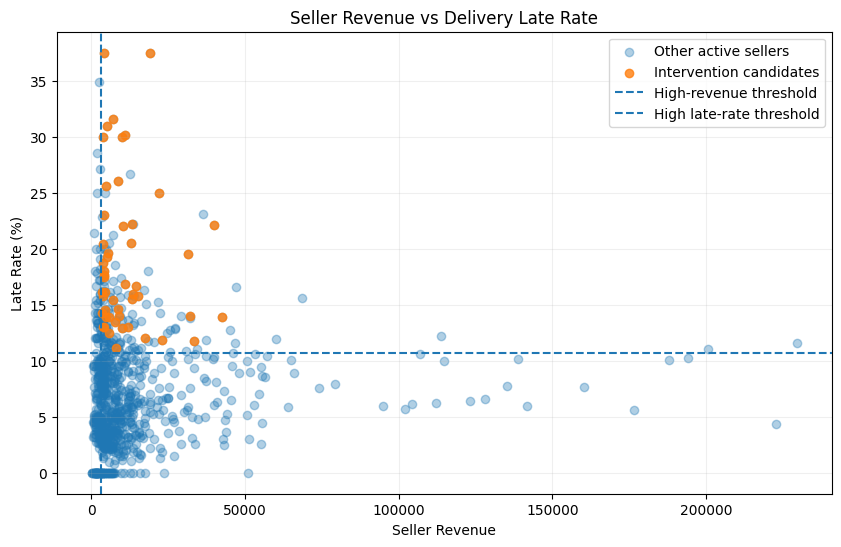

In [43]:
import matplotlib.pyplot as plt

# Sellers with enough delivered orders
active_sellers = seller_master[
    seller_master['delivered_orders'] >= MIN_DELIVERED_ORDERS
].copy()

plt.figure(figsize=(10, 6))

# All active sellers
plt.scatter(
    active_sellers['revenue'],
    active_sellers['late_rate'],
    alpha=0.35,
    label='Other active sellers'
)

# Intervention candidates
plt.scatter(
    intervention_watchlist['revenue'],
    intervention_watchlist['late_rate'],
    alpha=0.8,
    label='Intervention candidates'
)

# Threshold lines
plt.axvline(
    HIGH_REVENUE_THRESHOLD,
    linestyle='--',
    label='High-revenue threshold'
)

plt.axhline(
    HIGH_LATE_RATE,
    linestyle='--',
    label='High late-rate threshold'
)

plt.xlabel('Seller Revenue')
plt.ylabel('Late Rate (%)')
plt.title('Seller Revenue vs Delivery Late Rate')
plt.legend()
plt.grid(alpha=0.2)

plt.show()

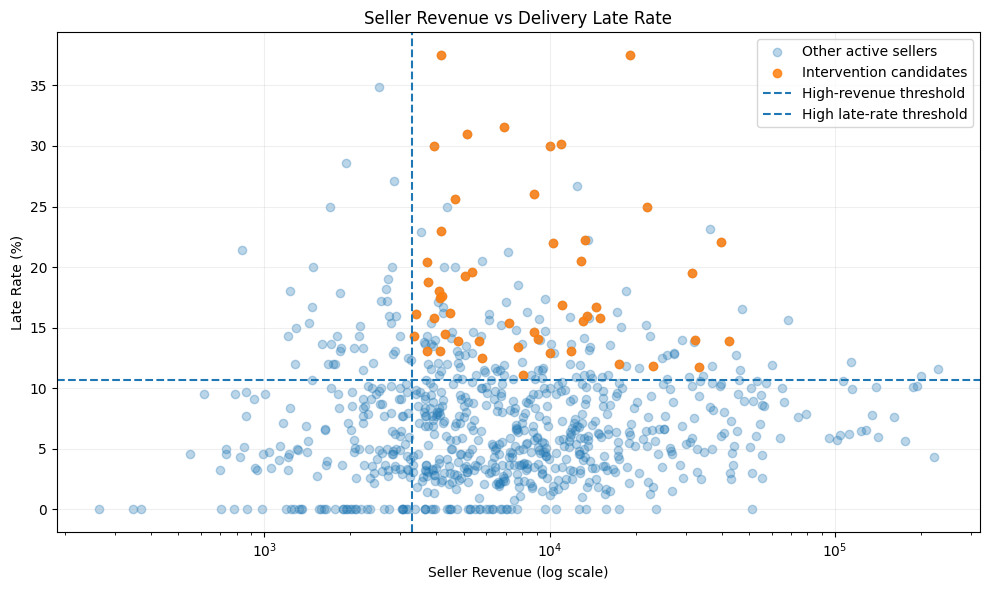

In [44]:
import matplotlib.pyplot as plt

active_sellers = seller_master[
    seller_master['delivered_orders'] >= MIN_DELIVERED_ORDERS
].copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    active_sellers['revenue'],
    active_sellers['late_rate'],
    alpha=0.30,
    label='Other active sellers'
)

plt.scatter(
    intervention_watchlist['revenue'],
    intervention_watchlist['late_rate'],
    alpha=0.85,
    label='Intervention candidates'
)

plt.axvline(
    HIGH_REVENUE_THRESHOLD,
    linestyle='--',
    label='High-revenue threshold'
)

plt.axhline(
    HIGH_LATE_RATE,
    linestyle='--',
    label='High late-rate threshold'
)

plt.xscale('log')

plt.xlabel('Seller Revenue (log scale)')
plt.ylabel('Late Rate (%)')
plt.title('Seller Revenue vs Delivery Late Rate')

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

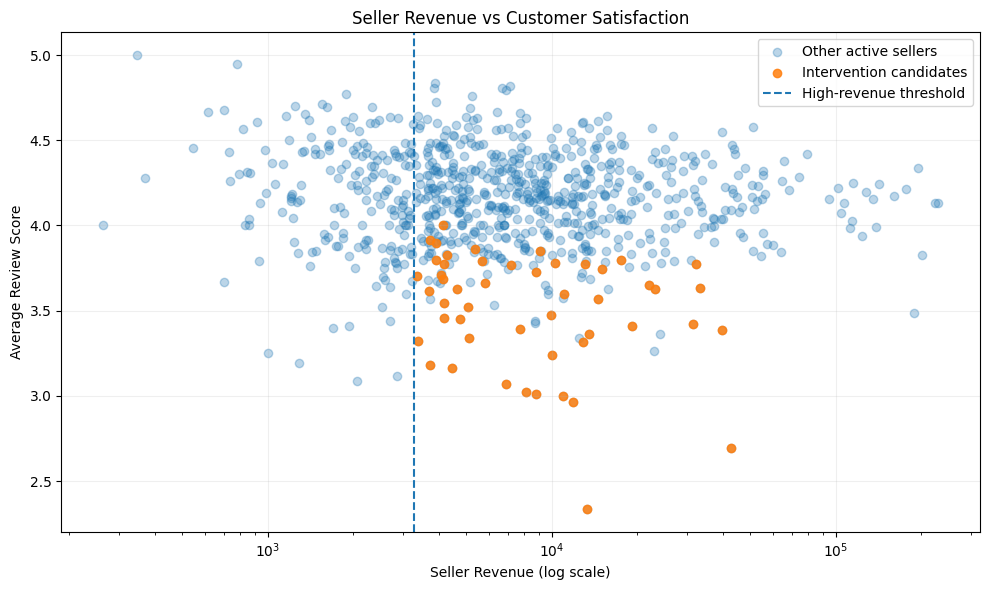

In [45]:
import matplotlib.pyplot as plt

active_sellers = seller_master[
    seller_master['delivered_orders'] >= MIN_DELIVERED_ORDERS
].copy()

# Remove sellers without a review score
active_sellers = active_sellers[
    active_sellers['avg_review_score'].notna()
]

plt.figure(figsize=(10, 6))

# Other active sellers
plt.scatter(
    active_sellers['revenue'],
    active_sellers['avg_review_score'],
    alpha=0.30,
    label='Other active sellers'
)

# Intervention candidates
plt.scatter(
    intervention_watchlist['revenue'],
    intervention_watchlist['avg_review_score'],
    alpha=0.85,
    label='Intervention candidates'
)

# High revenue threshold
plt.axvline(
    HIGH_REVENUE_THRESHOLD,
    linestyle='--',
    label='High-revenue threshold'
)

plt.xlabel('Seller Revenue (log scale)')
plt.ylabel('Average Review Score')
plt.title('Seller Revenue vs Customer Satisfaction')

plt.xscale('log')

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

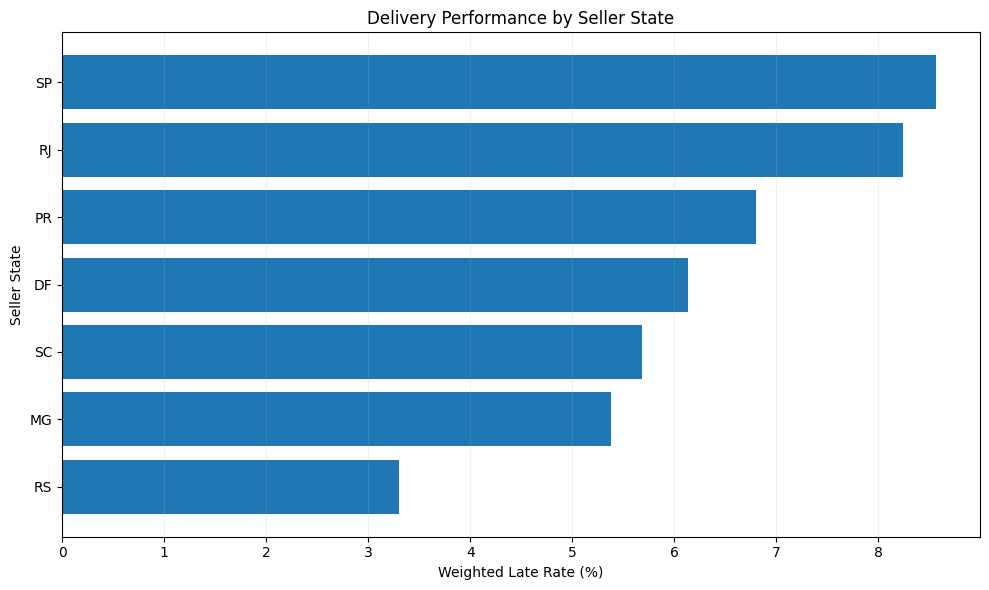

In [46]:
import matplotlib.pyplot as plt

# Keep states with at least 10 active sellers
state_chart = state_delivery[
    state_delivery['sellers'] >= 10
].copy()

# Sort from highest to lowest late rate
state_chart = state_chart.sort_values(
    'weighted_late_rate',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    state_chart['seller_state'],
    state_chart['weighted_late_rate']
)

plt.xlabel('Weighted Late Rate (%)')
plt.ylabel('Seller State')
plt.title('Delivery Performance by Seller State')

plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

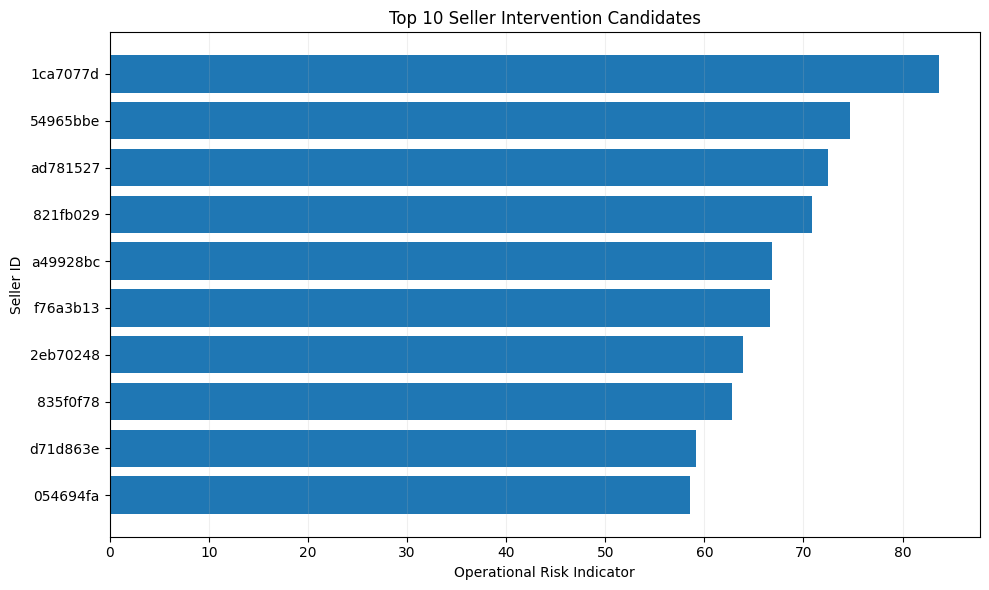

In [47]:
import matplotlib.pyplot as plt

# Select top 10 intervention candidates
top_10_intervention = (
    intervention_watchlist_ranked
    .head(10)
    .sort_values('risk_indicator', ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_intervention['seller_id'].str[:8],
    top_10_intervention['risk_indicator']
)

plt.xlabel('Operational Risk Indicator')
plt.ylabel('Seller ID')
plt.title('Top 10 Seller Intervention Candidates')

plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

# Issue #8 — Seller Performance and Intervention Analysis

## Objective

The objective of this analysis is to identify sellers that contribute significant marketplace value but may require operational intervention because of delivery delays and weaker customer experience.

The analysis also identifies healthy sellers that can be used as benchmark examples and examines whether seller geography is associated with delivery performance.

Methodology

Seller performance was evaluated using four main dimensions:

1. Business contribution — seller revenue and order volume.
2. Delivery performance — delivered orders and late-delivery rate.
3. Customer satisfaction — average review score and low-review rate.
4. Seller geography — seller state and state-level delivery performance.

To avoid unstable comparisons from very small sellers, sellers with at least 20 delivered orders were used for comparative delivery and watchlist analysis.

The thresholds for high revenue, high late rate, and high low-review rate were based on the 75th percentile of the respective distributions.

## Watchlist Criteria and Results

A seller was considered an intervention candidate when all of the following conditions were met:

- Revenue > R$3,280.83 (75th percentile)
- At least 20 delivered orders
- Late rate > 10.69% (75th percentile)
- Low-review rate > 21.43% (75th percentile)

Using these criteria, 50 sellers were identified as intervention candidates.

These sellers combine relatively high marketplace contribution with delivery and customer-experience concerns and should be prioritized for further operational investigation.

## Healthy Seller Benchmark

The analysis identified 435 healthy sellers that met the following conditions:

- Revenue > R$3,280.83
- At least 20 delivered orders
- Late rate ≤ 10.69%
- Low-review rate ≤ 21.43%

These sellers combine strong marketplace contribution with relatively good delivery and customer-experience performance.

They can be used as benchmark examples to understand practices associated with reliable fulfilment and better customer satisfaction.

## Key Findings

1. High-value sellers and delivery risk

The analysis identified sellers with relatively high revenue and above-threshold late-delivery rates. The intervention watchlist contains 50 sellers that also show elevated low-review rates.

2. Customer experience

The intervention candidates generally show weaker average review scores and higher low-review rates than many other active sellers. This suggests that delivery problems and customer-experience concerns can occur together.

3. Healthy sellers

A group of 435 healthy sellers combines relatively strong revenue contribution with better delivery and review performance. These sellers provide useful benchmark examples.

### 4. Geographic variation

Delivery performance varies across seller states. Among states with at least 10 active sellers, SP and RJ have relatively higher weighted late rates, while RS has a lower weighted late rate.

However, geography should be treated as a contextual factor rather than a standalone explanation because seller counts and operating conditions vary across states.

## Business Recommendations

For intervention sellers

- Prioritize high-value sellers that show both delivery delays and weak customer experience.
- Review fulfilment, dispatch and shipping processes for repeated late deliveries.
- Monitor 1–2 star reviews to identify recurring customer complaints.
- Track the performance of intervention sellers periodically after corrective actions.

For healthy sellers

- Study the operational practices of healthy high-value sellers.
- Use these sellers as benchmark examples for fulfilment and customer-service practices.
- Share useful operational practices with sellers requiring improvement.
- Continue supporting healthy sellers so that strong performance is maintained.

Geography

- Use seller geography as a supporting factor when investigating delivery problems.
- Avoid treating a state as inherently high-risk when the number of sellers is very small.

## Limitations

- Seller performance can be unstable when the number of delivered orders is very small. Therefore, a minimum of 20 delivered orders was used for comparative analysis.
- Some seller states have very few active sellers, so state-level comparisons should be interpreted cautiously.
- The intervention watchlist identifies sellers for further investigation; it does not prove that sellers are solely responsible for delivery delays or poor reviews.
- The Operational Risk Indicator used for prioritization is a simple exploratory measure calculated as late rate + low-review rate. It is not a formal statistical risk score.
- Review scores may be affected by factors other than delivery performance, such as product quality, pricing or customer expectations.

## Conclusion

This seller analysis identified important differences in seller contribution, delivery performance and customer experience.

Using data-driven thresholds, 50 sellers were identified as intervention candidates because they combine relatively high revenue with higher late-delivery and low-review rates. At the same time, 435 healthy sellers were identified as potential benchmark examples.

The analysis also shows variation in delivery performance across seller states, although geographic comparisons need to be interpreted carefully because seller volumes differ substantially.

Overall, the findings suggest that the marketplace can improve seller performance by prioritizing high-value problem sellers for operational intervention and using healthy sellers as benchmarks for better fulfilment and customer experience.